## Import Libraries

In [3]:
!pip install pandera
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
import pandera as pa
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0/2 [typeguard]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   -------------------- ------------------- 1/2 [pandera]
   --------

## Load the Dataset

In [5]:
df = pd.read_csv('order_data.csv')

print(f" Dataset loaded!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

 Dataset loaded!
Shape: 1200 rows, 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


## Exploratory Data Analysis (EDA)
### Basic Info

In [6]:
print("=" * 55)
print("  BASIC DATASET INFORMATION")
print("=" * 55)

print("\n Column Names:")
print(df.columns.tolist())

print("\n Data Types:")
print(df.dtypes)

print("\n Shape:")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

  BASIC DATASET INFORMATION

 Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

 Data Types:
OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

 Shape:
Rows: 1200  |  Columns: 14


### Missing Values Analysis

Columns with missing values:
            Missing Count  Missing %
CouponCode            309      25.75


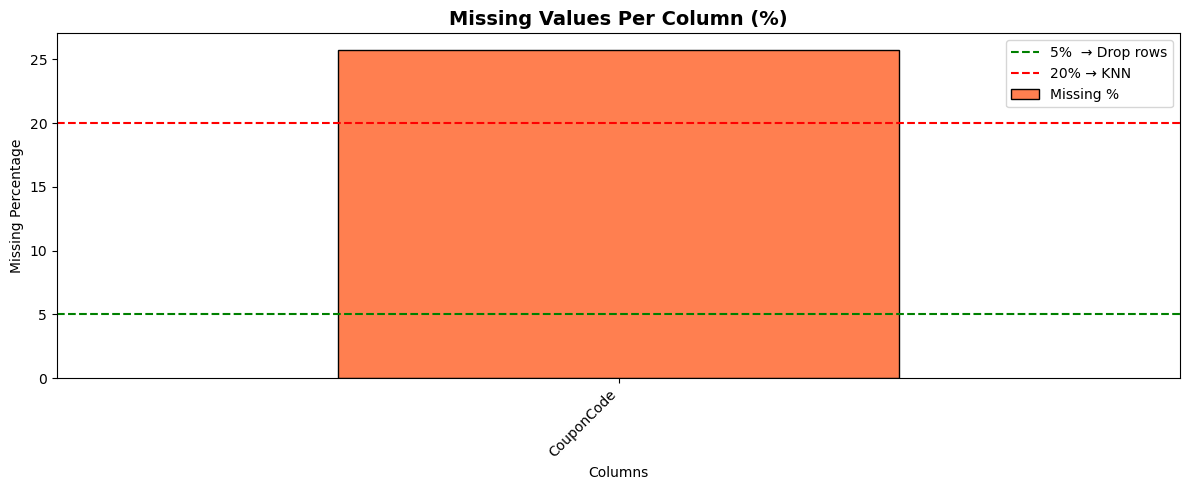

 Chart saved as missing_values.png


In [7]:
missing_count   = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
}).sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])

# Bar chart
plt.figure(figsize=(12, 5))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
if len(cols_with_missing) > 0:
    cols_with_missing['Missing %'].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Per Column (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Columns')
    plt.ylabel('Missing Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(y=5,  color='green', linestyle='--', linewidth=1.5, label='5%  → Drop rows')
    plt.axhline(y=20, color='red',   linestyle='--', linewidth=1.5, label='20% → KNN')
    plt.legend()
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Chart saved as missing_values.png")
else:
    print(" No missing values found!")

### Statistical Summary & Distributions

In [8]:
print(" Statistical Summary (Numeric Columns):")
print(df.describe().round(2))

print("\n Categorical Columns Value Counts:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols[:5]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(5))

 Statistical Summary (Numeric Columns):
       Quantity  UnitPrice  ItemsInCart  TotalPrice
count   1200.00    1200.00      1200.00     1200.00
mean       2.95     356.41         5.48     1053.97
std        1.41     197.18         2.28      819.86
min        1.00      11.39         1.00       11.39
25%        2.00     186.06         4.00      410.52
50%        3.00     364.21         5.00      823.62
75%        4.00     521.57         7.00     1578.48
max        5.00     699.93        10.00     3456.40

 Categorical Columns Value Counts:

--- OrderID ---
OrderID
ORD200000    1
ORD200001    1
ORD200002    1
ORD200003    1
ORD200004    1
Name: count, dtype: int64

--- Date ---
Date
2023-08-20    8
2024-04-07    7
2024-12-19    6
2025-03-15    6
2024-11-24    6
Name: count, dtype: int64

--- CustomerID ---
CustomerID
C38840    2
C14847    2
C35852    2
C97593    2
C46651    2
Name: count, dtype: int64

--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Des

### Distribution Plots

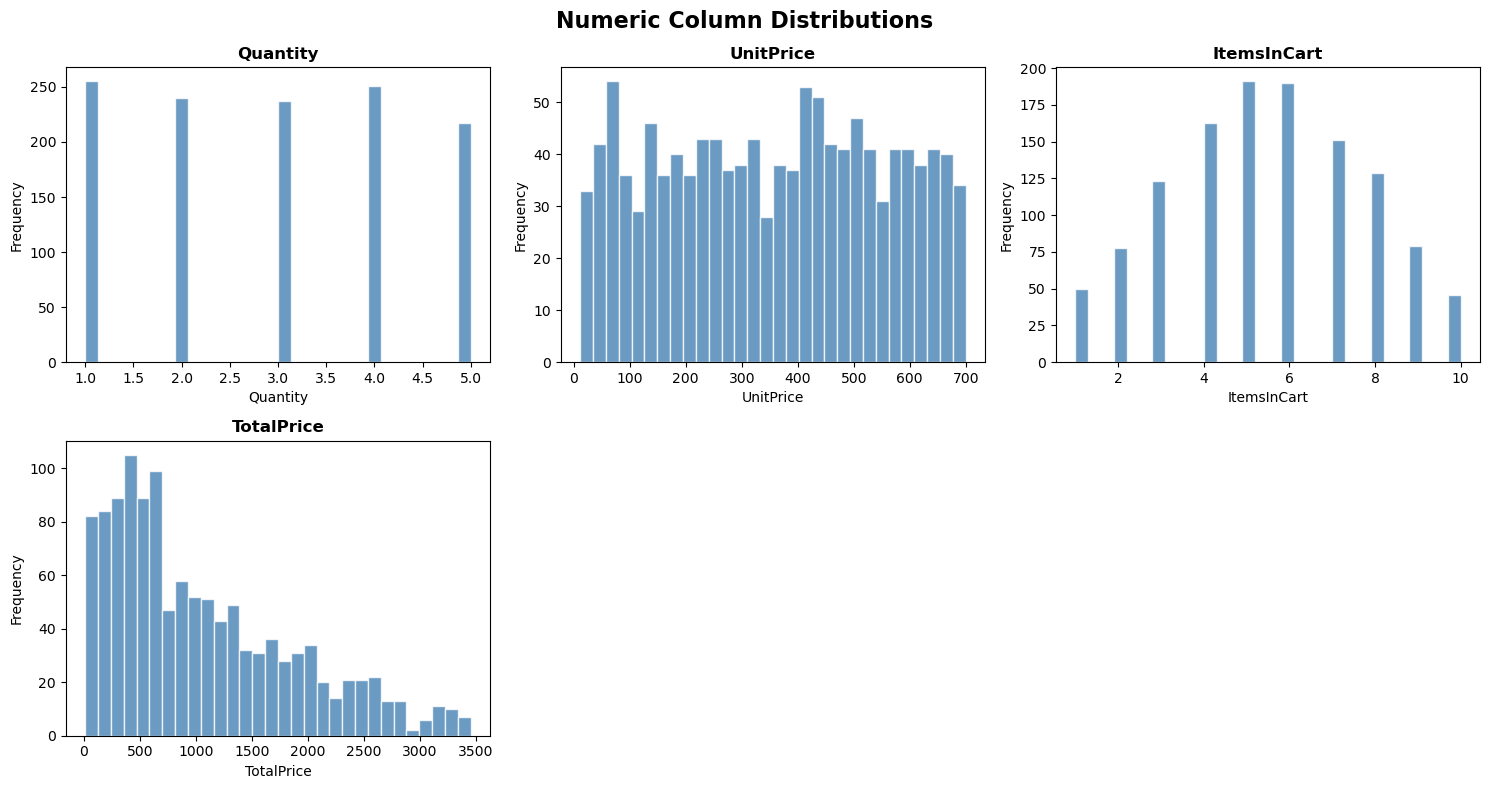

 Distribution plots saved!


In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = min(len(num_cols), 6)
cols_to_plot = num_cols[:n]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(cols_to_plot), 6):
    axes[j].set_visible(False)

plt.suptitle('Numeric Column Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Distribution plots saved!")

##  Handle Missing Values
**Decision Matrix :**
| Missing % | Method |
|-----------|--------|
| < 5% | Drop rows |
| 5% – 20% | Median (numeric) / Mode (categorical) |
| > 20% | KNN Imputation |


In [10]:
df_clean = df.copy()

print("Applying Missing Value Decision Matrix...")
print("-" * 55)

for col in df_clean.columns:
    pct = (df_clean[col].isnull().sum() / len(df_clean)) * 100

    if pct == 0:
        continue

    elif pct < 5:
        df_clean.dropna(subset=[col], inplace=True)
        print(f" [{col}]  {pct:.1f}%  →  Dropped rows (< 5%)")

    elif pct <= 20:
        if df_clean[col].dtype == 'object':
            val = df_clean[col].mode()[0]
            df_clean[col].fillna(val, inplace=True)
            print(f" [{col}]  {pct:.1f}%  →  Mode = '{val}'")
        else:
            val = df_clean[col].median()
            df_clean[col].fillna(val, inplace=True)
            print(f" [{col}]  {pct:.1f}%  →  Median = {val:.2f}")

    else:
        if df_clean[col].dtype != 'object':
            imputer = KNNImputer(n_neighbors=5)
            df_clean[[col]] = imputer.fit_transform(df_clean[[col]])
            print(f" [{col}]  {pct:.1f}%  →  KNN Imputation (> 20%)")
        else:
            val = df_clean[col].mode()[0]
            df_clean[col].fillna(val, inplace=True)
            print(f" [{col}]  {pct:.1f}%  →  Mode imputation")

print("-" * 55)
print(f"\n Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"📐 Shape after cleaning: {df_clean.shape}")

Applying Missing Value Decision Matrix...
-------------------------------------------------------
 [CouponCode]  25.8%  →  Mode imputation
-------------------------------------------------------

 Missing values remaining: 0
📐 Shape after cleaning: (1200, 14)


## Outlier Detection: Z-Score Method
Rows with |Z-score| > 3 are considered outliers.

 Outliers found via Z-Score (|z| > 3): 0 rows
 That is 0.00% of the data


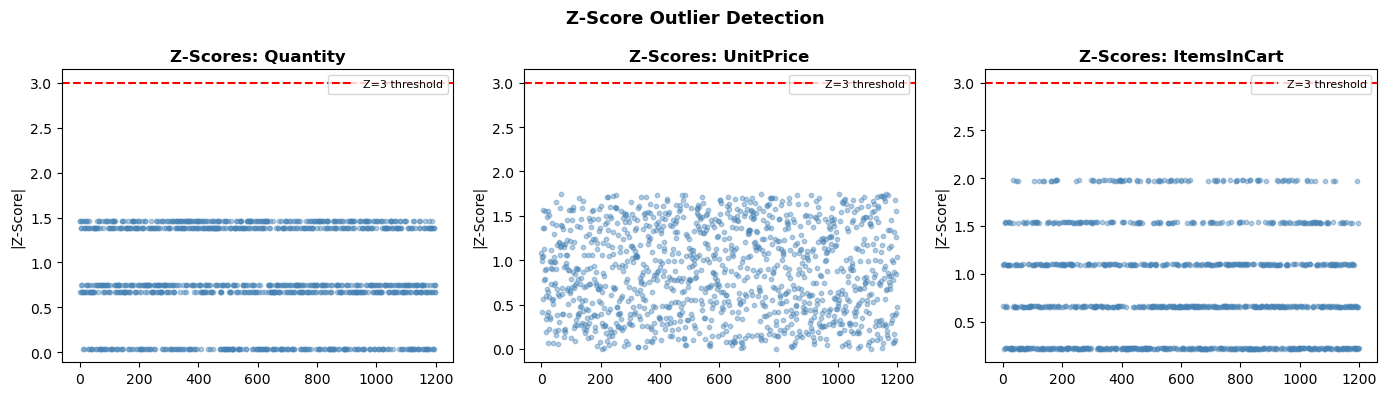

 Z-Score plot saved!


In [11]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

z_scores   = np.abs(stats.zscore(df_clean[num_cols].fillna(0)))
outlier_mask = (z_scores > 3).any(axis=1)

print(f" Outliers found via Z-Score (|z| > 3): {outlier_mask.sum()} rows")
print(f" That is {(outlier_mask.sum()/len(df_clean)*100):.2f}% of the data")

cols_to_show = num_cols[:3]
fig, axes = plt.subplots(1, len(cols_to_show), figsize=(14, 4))
if len(cols_to_show) == 1:
    axes = [axes]

for i, col in enumerate(cols_to_show):
    z = np.abs(stats.zscore(df_clean[col].fillna(0)))
    axes[i].scatter(range(len(z)), z, alpha=0.4, color='steelblue', s=10)
    axes[i].axhline(y=3, color='red', linestyle='--', label='Z=3 threshold')
    axes[i].set_title(f'Z-Scores: {col}', fontweight='bold')
    axes[i].set_ylabel('|Z-Score|')
    axes[i].legend(fontsize=8)

plt.suptitle('Z-Score Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('zscore_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Z-Score plot saved!")

##  Outlier Treatment: IQR Winsorization
We **cap** extreme values instead of deleting rows — preserves dataset size.

 [Quantity]  Outliers: 0  →  Winsorized to [-1.00, 7.00]
 [UnitPrice]  Outliers: 0  →  Winsorized to [-317.20, 1024.83]
 [ItemsInCart]  Outliers: 0  →  Winsorized to [-0.50, 11.50]
 [TotalPrice]  Outliers: 8  →  Winsorized to [-1341.41, 3330.41]

 IQR Report:
     Column     Q1      Q3     IQR  Lower Bound  Upper Bound  Outliers Winsorized
   Quantity   2.00    4.00    2.00        -1.00         7.00                    0
  UnitPrice 186.06  521.57  335.51      -317.20      1024.83                    0
ItemsInCart   4.00    7.00    3.00        -0.50        11.50                    0
 TotalPrice 410.52 1578.48 1167.96     -1341.41      3330.41                    8


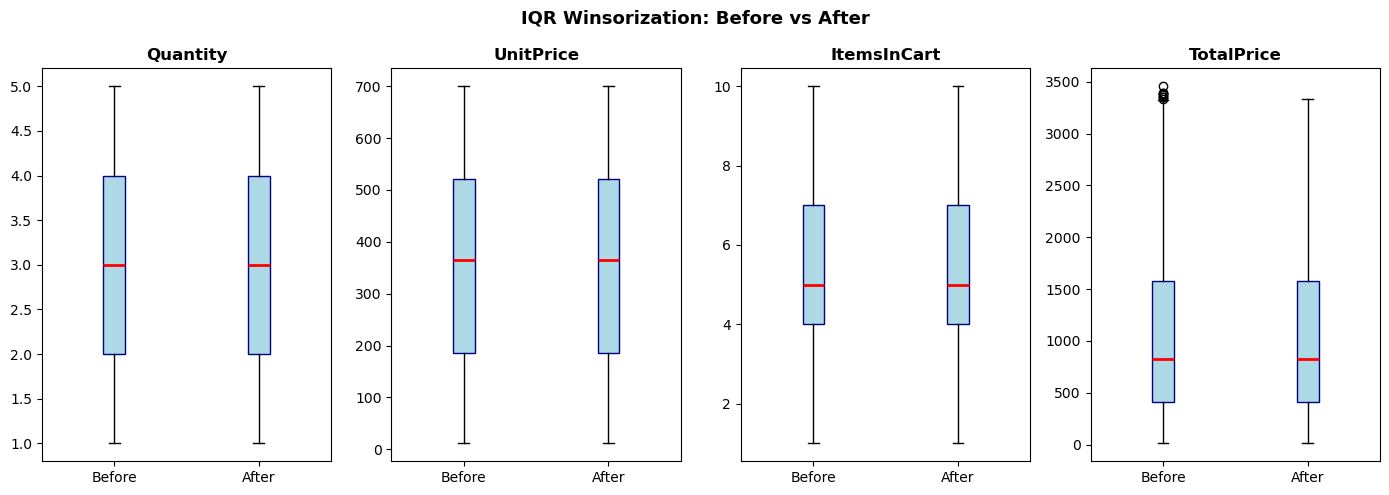

 Box plots saved!


In [12]:
df_no_outliers = df_clean.copy()
outlier_report = []

for col in num_cols:
    Q1  = df_no_outliers[col].quantile(0.25)
    Q3  = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)

    outlier_report.append({
        'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
        'Upper Bound': round(upper,2), 'Outliers Winsorized': n_out
    })
    print(f" [{col}]  Outliers: {n_out}  →  Winsorized to [{lower:.2f}, {upper:.2f}]")

print("\n IQR Report:")
print(pd.DataFrame(outlier_report).to_string(index=False))

# Box plots before vs after
n_plot = min(len(num_cols), 4)
fig, axes = plt.subplots(1, n_plot, figsize=(14, 5))
if n_plot == 1:
    axes = [axes]
for i, col in enumerate(num_cols[:n_plot]):
    axes[i].boxplot(
        [df_clean[col].dropna(), df_no_outliers[col].dropna()],
        labels=['Before', 'After'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('IQR Winsorization: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Box plots saved!")

df_clean = df_no_outliers.copy()

## Feature Engineering
Creating **5 new predictive features** from existing columns.

In [13]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Feature 1: Revenue per item
df_clean['RevenuePerItem'] = (df_clean['TotalPrice'] / df_clean['Quantity']).round(2)
print(" Feature 1: RevenuePerItem = TotalPrice / Quantity")
print(f"   Preview: {df_clean['RevenuePerItem'].head(3).tolist()}")

# Feature 2: Coupon used?
df_clean['HasCoupon'] = df_clean['CouponCode'].notna().astype(int)
print("\n Feature 2: HasCoupon = 1 if coupon applied, 0 otherwise")
print(f"   Distribution: {df_clean['HasCoupon'].value_counts().to_dict()}")

# Feature 3: Order Month
df_clean['OrderMonth'] = df_clean['Date'].dt.month
print("\n Feature 3: OrderMonth = month number (1-12) from Date")
print(f"   Unique months: {sorted(df_clean['OrderMonth'].dropna().unique().tolist())}")

# Feature 4: Is High Value order?
median_price = df_clean['TotalPrice'].median()
df_clean['IsHighValue'] = (df_clean['TotalPrice'] > median_price).astype(int)
print(f"\n Feature 4: IsHighValue = 1 if TotalPrice > median ({median_price:.2f})")
print(f"   High value orders: {df_clean['IsHighValue'].sum()}")

# Feature 5: Day of Week
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
print("\n Feature 5: DayOfWeek = 0 (Mon) to 6 (Sun)")
print(f"   Distribution: {df_clean['DayOfWeek'].value_counts().sort_index().to_dict()}")

print(f"\n Shape after feature engineering: {df_clean.shape}")
print("\n New features preview:")
df_clean[['TotalPrice','Quantity','RevenuePerItem',
          'HasCoupon','OrderMonth','IsHighValue','DayOfWeek']].head(8)

 Feature 1: RevenuePerItem = TotalPrice / Quantity
   Preview: [570.62, 151.35, 550.68]

 Feature 2: HasCoupon = 1 if coupon applied, 0 otherwise
   Distribution: {1: 1200}

 Feature 3: OrderMonth = month number (1-12) from Date
   Unique months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

 Feature 4: IsHighValue = 1 if TotalPrice > median (823.62)
   High value orders: 600

 Feature 5: DayOfWeek = 0 (Mon) to 6 (Sun)
   Distribution: {0: 174, 1: 165, 2: 163, 3: 166, 4: 174, 5: 172, 6: 186}

 Shape after feature engineering: (1200, 19)

 New features preview:


,TotalPrice,Quantity,RevenuePerItem,HasCoupon,OrderMonth,IsHighValue,DayOfWeek
0,2853.10,5,570.62,1,1,1,2
1,302.70,2,151.35,1,8,0,4
2,2753.40,5,550.68,1,2,1,1
3,273.19,1,273.19,1,10,0,6
4,2504.04,4,626.01,1,5,1,3
5,491.72,2,245.86,1,10,0,0
6,664.42,1,664.42,1,6,0,1
7,747.75,5,149.55,1,5,0,4


## One-Hot Encoding
Converts categorical text columns into numeric binary columns so ML models can use them.

In [14]:
cols_to_encode = ['PaymentMethod', 'Product', 'ReferralSource', 'OrderStatus']
cols_to_encode = [c for c in cols_to_encode if c in df_clean.columns]

print(f"Encoding columns: {cols_to_encode}")
print("\nBefore encoding:")
for col in cols_to_encode:
    print(f"  {col}: {df_clean[col].unique().tolist()}")

df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(f"\n {len(cols_to_encode)} columns → {len(new_cols)} binary columns created")
print(f" Shape: {df_clean.shape}  →  {df_encoded.shape}")
print(f"\nNew columns: {new_cols}")

Encoding columns: ['PaymentMethod', 'Product', 'ReferralSource', 'OrderStatus']

Before encoding:
  PaymentMethod: ['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash']
  Product: ['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']
  ReferralSource: ['Instagram', 'Referral', 'Email', 'Facebook', 'Google']
  OrderStatus: ['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending']

 4 columns → 18 binary columns created
 Shape: (1200, 19)  →  (1200, 33)

New columns: ['PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped']


## Multicollinearity Check
Find features that are too correlated with each other (>0.80) and remove the weaker one.

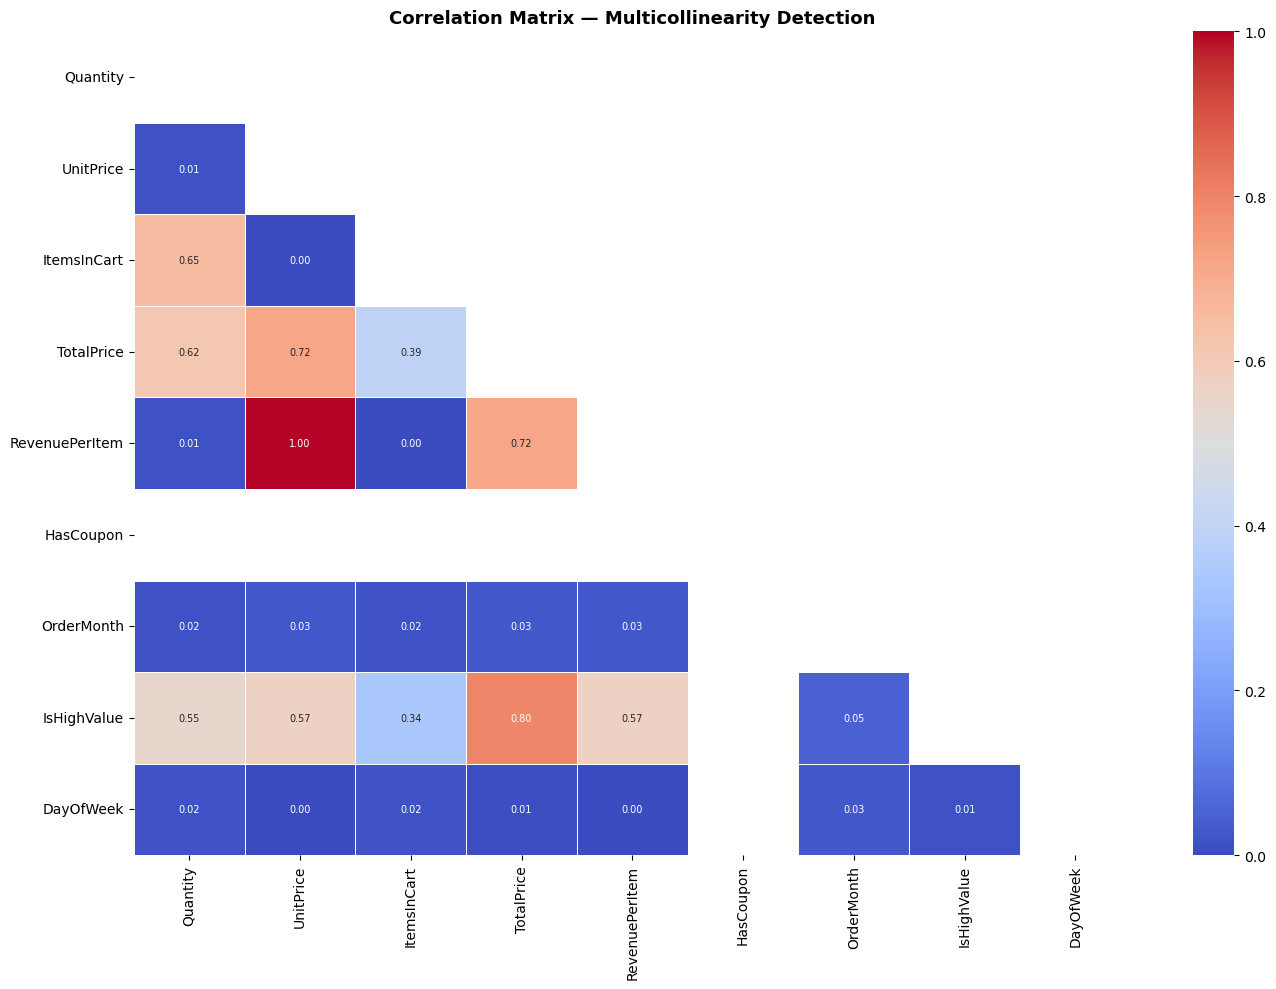

 Correlation matrix saved!

  Highly correlated columns (>0.80): ['RevenuePerItem']
 Dropped: ['RevenuePerItem']
 Shape after check: (1200, 32)


In [15]:
num_df = df_encoded.select_dtypes(include=np.number)
corr_matrix = num_df.corr().abs()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7},
    vmin=0, vmax=1
)
plt.title('Correlation Matrix — Multicollinearity Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation matrix saved!")

# Drop features with correlation > 0.80
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop = [col for col in upper.columns if any(upper[col] > 0.80)]

if cols_to_drop:
    print(f"\n  Highly correlated columns (>0.80): {cols_to_drop}")
    df_encoded.drop(columns=cols_to_drop, inplace=True)
    print(f" Dropped: {cols_to_drop}")
else:
    print("\n No multicollinearity detected above 0.80 threshold!")

print(f" Shape after check: {df_encoded.shape}")

## Pandera Data Validation

In [17]:
schema_checks = {}

if 'TotalPrice' in df_encoded.columns:
    schema_checks['TotalPrice'] = pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=False)

if 'Quantity' in df_encoded.columns:
    df_encoded['Quantity'] = df_encoded['Quantity'].astype('int64')
    schema_checks['Quantity'] = pa.Column(pa.Int, pa.Check.greater_than(0), nullable=False)

if 'OrderMonth' in df_encoded.columns:
    df_encoded['OrderMonth'] = df_encoded['OrderMonth'].astype('int64')  # ← fix
    schema_checks['OrderMonth'] = pa.Column(pa.Int, pa.Check.in_range(1, 12), nullable=True)

if 'IsHighValue' in df_encoded.columns:
    df_encoded['IsHighValue'] = df_encoded['IsHighValue'].astype('int64')
    schema_checks['IsHighValue'] = pa.Column(pa.Int, pa.Check.isin([0, 1]), nullable=False)

if 'HasCoupon' in df_encoded.columns:
    df_encoded['HasCoupon'] = df_encoded['HasCoupon'].astype('int64')
    schema_checks['HasCoupon'] = pa.Column(pa.Int, pa.Check.isin([0, 1]), nullable=False)

if 'RevenuePerItem' in df_encoded.columns:
    schema_checks['RevenuePerItem'] = pa.Column(float, pa.Check.greater_than(0), nullable=True)

schema = pa.DataFrameSchema(schema_checks)

try:
    schema.validate(df_encoded, lazy=True)
    print(" ALL PANDERA VALIDATION CHECKS PASSED!")
    print("   Your dataset meets all data quality contracts.")
except pa.errors.SchemaErrors as e:
    print("  Some validation issues found:")
    print(e.failure_cases)

 ALL PANDERA VALIDATION CHECKS PASSED!
   Your dataset meets all data quality contracts.


## Final Summary Report

In [18]:
print("=" * 50)
print("   DATA CLEANING - FINAL SUMMARY REPORT")
print("=" * 50)
print(f"Original rows    : {df.shape[0]}")
print(f"Final rows       : {df_encoded.shape[0]}")
print(f"Original columns : {df.shape[1]}")
print(f"Final columns    : {df_encoded.shape[1]}")
print("=" * 50)
print("COMPLETED TASKS:")
print("  EDA - distributions, stats, missing analysis")
print("  Missing values - Drop / Median / KNN")
print("  Outlier detection - Z-Score method")
print("  Outlier treatment - IQR Winsorization")
print("  Feature engineering - 5 new columns")
print("  One-Hot Encoding - categorical to numeric")
print("  Multicollinearity check - 0.80 threshold")
print("  Pandera schema validation - data contracts")
print("=" * 50)

print("\nFinal dataset preview:")
df_encoded.head()

   DATA CLEANING - FINAL SUMMARY REPORT
Original rows    : 1200
Final rows       : 1200
Original columns : 14
Final columns    : 32
COMPLETED TASKS:
  EDA - distributions, stats, missing analysis
  Missing values - Drop / Median / KNN
  Outlier detection - Z-Score method
  Outlier treatment - IQR Winsorization
  Feature engineering - 5 new columns
  One-Hot Encoding - categorical to numeric
  Multicollinearity check - 0.80 threshold
  Pandera schema validation - data contracts

Final dataset preview:


,OrderID,Date,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,TotalPrice,...,Product_Printer,Product_Tablet,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped
0,ORD200000,2023-01-04,C72649,5,570.62,928 Main St,TRK37947903,7,SAVE10,2853.10,...,False,False,False,False,True,False,False,False,False,True
1,ORD200001,2024-08-23,C75739,2,151.35,823 Main St,TRK91186779,3,SAVE10,302.70,...,False,False,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,5,550.68,512 Main St,TRK42903982,8,FREESHIP,2753.40,...,False,True,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,1,273.19,275 Main St,TRK62788070,5,SAVE10,273.19,...,False,False,True,False,False,False,False,False,True,False
4,ORD200004,2025-05-08,C81840,4,626.01,668 Main St,TRK29241424,8,SAVE10,2504.04,...,True,False,False,False,False,False,True,False,False,False


##  Save Cleaned Dataset

In [20]:
output_file = 'cleaned_orders_dataset.csv'
df_encoded.to_csv(output_file, index=False)

print(f" Cleaned dataset saved as: '{output_file}'")
print(f" Final shape: {df_encoded.shape}")
print(f" Total features: {df_encoded.shape[1]}")
print()


 Cleaned dataset saved as: 'cleaned_orders_dataset.csv'
 Final shape: (1200, 32)
 Total features: 32

